<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
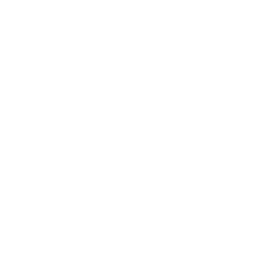
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Lääke-esittelijöiden esittelytyön vaikuttavuus ja viiveiden valinta</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lääke- / kaupallinen analytiikka &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Arvioidaan lääkäreille suunnattujen esittelykäyntien ja näytejakelun vaikutusta erikoislääkkeen kuukausittaiseen reseptivolyymiin PROC AUTOREG -menetelmällä. Autokorreloituneet reseptikuviot otetaan huomioon asetuksella NLAG=3, ja BACKSTEP-optiolla poistetaan merkityksettömät viiveasteet automaattisesti. Kvantifioidaan kunkin lisäesittelykäynnin rajahyöty, jotta kenttätyövoiman kohdentamista ja alueiden jakoa koskevia päätöksiä voidaan tukea.

Synteettinen kuukausisarja on rajattu 100 havaintoon nykyisessä ajotilassa, mikä riittää palauttamaan esittelyyn, näytteisiin, lääkevalikoimaan ja kilpailijoihin liittyvät vaikutukset suurella tarkkuudella.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.DETAILING | Kuukausittaiset reseptit sekä esittely- ja näytemittarit | 100 |

---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen kuukausittainen esittely- ja resepti-
   aineisto erikoislääkevalmisteelle
   -------------------------------------------------------- */
TIEDOT work.detailing;
    CALL streaminit(42);
    PIDÄ prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    TEE month_seq = 1 ASTI 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* alueiden kierto 12 edustajan kesken */
        rep_id = cat('REP-', KIRJOITA(mod(month_seq - 1, 12) + 1, z3.));
        /* esittelykäynnit kuukaudessa */
        detail_visits = int(rand('normal', 8, 3));
        JOS detail_visits < 0 NIIN detail_visits = 0;
        JOS detail_visits > 20 NIIN detail_visits = 20;
        /* lääkäreille jätetyt näyteyksiköt */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* lääkevalikoiman status (binäärinen) */
        formulary_status = (rand('uniform') > 0.2);
        /* kilpailijan osuuspaine */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* kausi-indeksi */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3)-virheprosessi */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* reseptimalli */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        JOS new_rx < 0 NIIN new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        TULOSTE;
    LOPPU;
    POISTA prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    MUOTO obs_month monyy7.;
SUORITA;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

In [2]:
/* --------------------------------------------------------
   Reseptien ja esittelyn perustunnusluvut
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.detailing n mean std MIN MAX;
    MUUTTUJA new_rx total_rx detail_visits samples_left competitor_share;
    NIMIKE new_rx='Uudet reseptit' total_rx='Reseptit yhteensä' detail_visits='Esittelykäynnit' samples_left='Jätetyt näytteet' competitor_share='Kilpailijan osuus' formulary_status='Lääkevalikoimastatus';
    OTSIKKO 'Reseptien ja esittelyn perustunnusluvut';
SUORITA;

                                        Reseptien ja esittelyn perustunnusluvut                                         

                                                  The MEANS Procedure

 Variable          Label                      N            Mean        Std Dev        Minimum         Maximum
 ------------------------------------------------------------------------------------------------------------
 new_rx            Uudet reseptit           100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Reseptit yhteensä        100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Esittelykäynnit          100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Jätetyt näytteet         100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Kilpailijan osuus        100       0.2653000      0.1187090      0.0300000       0.5600000
 ------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                        Reseptien ja esittelyn perustunnusluvut                                         




NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


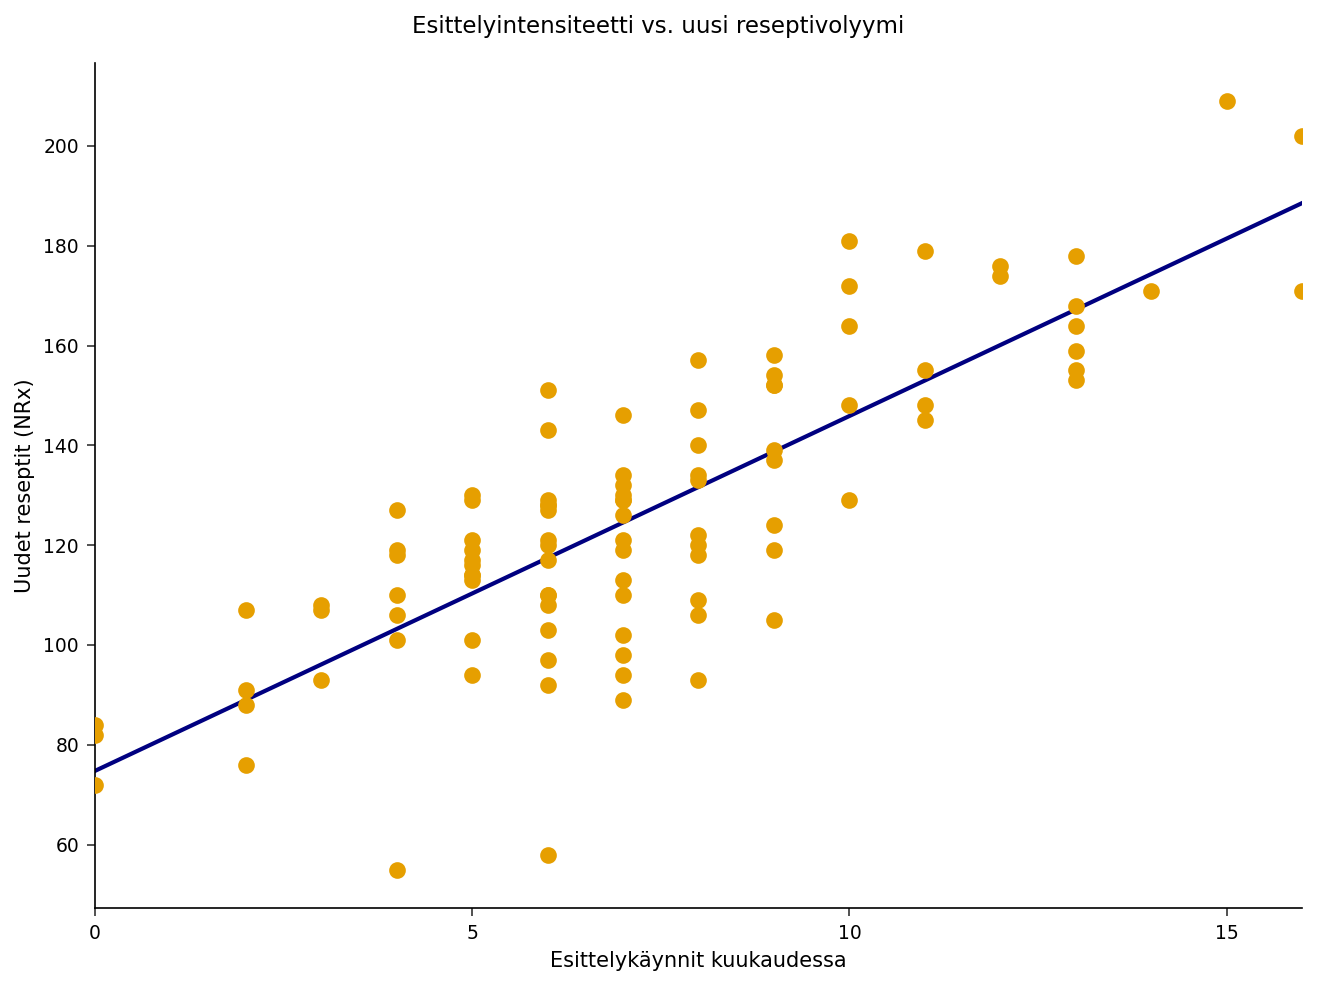

In [3]:
/* --------------------------------------------------------
   Esittelykäyntien ja uusien reseptien hajontakuvaaja
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS NIMIKE='Esittelykäynnit kuukaudessa';
    YAXIS NIMIKE='Uudet reseptit (NRx)';
    OTSIKKO 'Esittelyintensiteetti vs. uusi reseptivolyymi';
SUORITA;

---

In [4]:
/* --------------------------------------------------------
   Sovita autoregressiivinen malli BACKSTEP-viivevalinnalla.
   NLAG=3 testaa enintään kolme viivettä; BACKSTEP poistaa
   merkityksettömät viiveet automaattisesti.
   -------------------------------------------------------- */
PROSEDUURI autoreg TIEDOT=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    NIMIKE new_rx='Uudet reseptit' total_rx='Reseptit yhteensä' detail_visits='Esittelykäynnit' samples_left='Jätetyt näytteet' competitor_share='Kilpailijan osuus' formulary_status='Lääkevalikoimastatus';
    OTSIKKO 'Autoregressiivinen reseptimalli (AR(3), BACKSTEP)';
    TULOSTE out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
SUORITA;

                                        Reseptien ja esittelyn perustunnusluvut                                         


                     The AUTOREG Procedure

                     Dependent Variable   Uudet reseptit


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          Esittelykäynnit   2.715794   0.354343      7.66    0.0000

          Jätetyt näytteet   0.999741   0.067860     14.73    0.0000

          Lääkevalikoimastatus  24.776463   1.791581     13.83    0.0000

          Kilpailijan osuus -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990    


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Tallenna parametriestimaatit ROI-laskentaa varten
   -------------------------------------------------------- */
ODS TULOSTE parameterestimates=work.detail_params;

PROSEDUURI autoreg TIEDOT=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
    NIMIKE new_rx='Uudet reseptit' total_rx='Reseptit yhteensä' detail_visits='Esittelykäynnit' samples_left='Jätetyt näytteet' competitor_share='Kilpailijan osuus' formulary_status='Lääkevalikoimastatus';
    OTSIKKO 'Parametriestimaatit ROI-laskentaa varten';
SUORITA;

ODS TULOSTE CLOSE;

                                        Reseptien ja esittelyn perustunnusluvut                                         


                     The AUTOREG Procedure

                     Dependent Variable   Uudet reseptit


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          Esittelykäynnit   2.715794   0.354343      7.66    0.0000

          Jätetyt näytteet   0.999741   0.067860     14.73    0.0000

          Lääkevalikoimastatus  24.776463   1.791581     13.83    0.0000

          Kilpailijan osuus -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990    


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Laske esittelykäynnin rajakohtainen ROI.
   ODS ParameterEstimates -aineisto tallentaa Variable-
   sarakkeen isoin kirjaimin, joten suodata arvolla 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROSEDUURI TULOSTA TIEDOT=work.detail_params;
    MISSÄ variable = 'DETAIL_VISITS';
    OTSIKKO 'Esittelykäyntien rajavaikutus NRx:ään';
SUORITA;

                                         Esittelykäyntien rajavaikutus NRx:ään                                          

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Tulkinta

PROC AUTOREG sovitti reseptisarjan 100 kuukausihavaintoon. Kukin lisäesittelykäynti on yhteydessä **+2.72 uuteen reseptiin kuukaudessa** (estimaatti 2.7158, t = 7.66, p < 0.0001), ja jokainen lääkäreille jätetty näyteyksikkö lisää **+1.00 NRx** (estimaatti 0.9997, t = 14.73), mikä osoittaa, että näytteet vahvistavat mutta eivät korvaa henkilökohtaista markkinointia. Lääkevalikoimaan pääsy tuo **+24.78 NRx kuukaudessa** (t = 13.83), mikä korostaa managed care -pääsyä esittelytyön vaikuttavuuden edellytyksenä, kun taas kilpailijoiden markkinaosuudella on vahva negatiivinen vaikutus **-42.26 NRx osuusyksikköä kohti** (t = -6.96), mikä nostaa esiin kilpailupaineen alaiset alueet, joilla pelkkä esittelytyö voi olla riittämätöntä. Vakiotermi on 69.56.

Asetuksilla NLAG=3 ja BACKSTEP malli säilytti **kaksi autoregressiivistä viivettä**: viive 1 (kerroin -0.3700, t = -3.78) ja viive 2 (kerroin -0.1995, t = -2.04); viive 3 pudotettiin merkityksettömänä. Korjauksen jälkeinen Durbin-Watson-tunnusluku on **1.01**, mikä on yhä selvästi alle 2:n ja viittaa jäljelle jäävään positiiviseen autokorrelaatioon, joten AR(2)-rakenne selittää osan mutta ei kaikkea tämän sarjan sarjakorrelaatiosta. Sopivuustunnusluvut: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, log likelihood = -342.67.

Kenttätyövoiman suunnittelussa kannattaa keskittyä alueille, joilla lääkevalikoimaan pääsy on suotuisa ja kilpailijoiden osuus maltillinen, sillä siellä kunkin esittelykäynnin rajahyöty on suurin.

---

In [7]:
/* --------------------------------------------------------
   Vie sovitetut arvot ja parametrit kenttätyövoiman
   suunnittelun koontinäyttöä varten
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteuttajana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>